In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import torch
# torch.cuda.empty_cache()

In [3]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [4]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Processing train
INFO     | _get_names | Processing all
INFO     | _get_names | Image Pair Counts : MGO07_mapping_easy cam0 : 1595
INFO     | _get_names | Image Pair Counts : MGO07_mapping_easy cam1 : 1595
INFO     | _get_names | Image Pair Counts : MGO08_mapping_hard cam0 : 745
INFO     | _get_names | Image Pair Counts : MGO08_mapping_hard cam1 : 745
INFO     | _get_names | Processing normal
INFO     | _get_names | Processing blur
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam0 : 345
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam1 : 356
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam0 : 129
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam1 : 185
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam0 : 417
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam1 : 459
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam0 : 567
INFO     | _get_names | 

In [5]:
dl = dm.train_dataloader()

In [6]:
batch = next(iter(dl))

reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

torch.Size([120, 1, 32, 32]) torch.Size([120, 1, 32, 32])
torch.Size([120, 2]) torch.Size([120, 2])


In [7]:
# import torch
# import torch.nn.functional as F
# from skimage.feature import graycomatrix, graycoprops

# def calculate_texture_features(patches, num_levels=16):
#     """
#     Calculate texture features for a batch of grayscale patches.
    
#     Args:
#         patches (torch.Tensor): Input patches of shape (batch_size, 1, height, width).
#         num_levels (int): Number of intensity levels for quantization (default: 16).
    
#     Returns:
#         torch.Tensor: Texture features of shape (batch_size, num_features), where num_features = 4 (contrast, energy, entropy, homogeneity).
#     """
#     batch_size, _, height, width = patches.shape
#     texture_features = []

#     for i in range(batch_size):
#         # Convert patch to numpy array and normalize intensity to range [0, num_levels - 1]
#         patch = patches[i, 0].detach().cpu().numpy()
#         patch = ((patch - patch.min()) / (patch.max() - patch.min()) * (num_levels - 1)).astype('uint8')

#         # Compute GLCM
#         glcm = graycomatrix(patch, distances=[1], angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4], levels=num_levels, symmetric=True, normed=True)

#         # Extract features
#         contrast = graycoprops(glcm, 'contrast').mean()
#         energy = graycoprops(glcm, 'energy').mean()
#         homogeneity = graycoprops(glcm, 'homogeneity').mean()

#         # Calculate entropy manually
#         glcm_probs = glcm / glcm.sum()  # Normalize to probabilities
#         entropy = -np.sum(glcm_probs * np.log2(glcm_probs + 1e-6))  # Avoid log(0)

#         texture_features.append([contrast, energy, entropy, homogeneity])

#     return torch.tensor(texture_features, dtype=torch.float32, device=patches.device)


# print(f'{reference_patches.shape=}')
# texture_features = calculate_texture_features(reference_patches)

# print("Texture Features (Contrast, Energy, Entropy, Homogeneity):")
# print(f'{texture_features.shape=}')


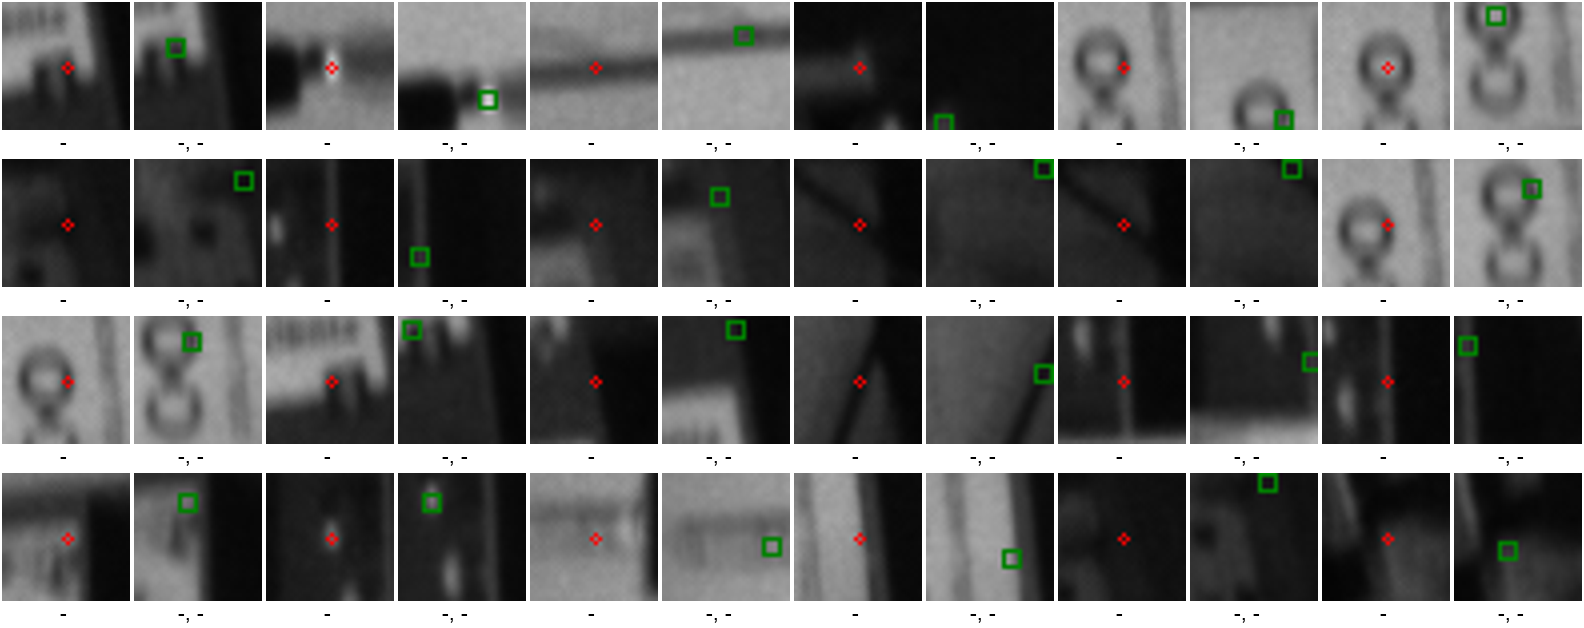

In [8]:
# batch = next(iter(dl))

# reference_patches = batch.reference_patches
# target_patches = batch.target_patches
# print(reference_patches.shape, target_patches.shape) 

# patch_level_reference_coords = batch.patch_level_reference_coords
# patch_level_target_coords = batch.patch_level_target_coords
# print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

count = 24 * 1

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    # rotations_true=batch.rotations,
    # rotations=batch.rotations,
    limit_count=count, 
    n_columns=6,
    just_gt=True,
)

# Rotation Interpretation
# How to get reference patch using target patch?
# Positive = Anti-clockwise movement
# Negative = Clockwise movement

In [9]:
# print("Texture Features (Contrast, Energy, Entropy, Homogeneity):")
# print(texture_features[:count])

In [10]:
# print(patch_level_target_coords.shape)

# pred = torch.rand(90, 2) * 2 - 1
# print(pred.shape)

# target = patch_level_target_coords

# # Scale pred from [-1, 1] to [0, 31]
# scaled_pred = (pred.float() + 1) * 15.5 
# print(scaled_pred.shape)

# difference = torch.abs(target - target)
# print(difference.shape)

# # Check which differences exceed N pixels
# exceeds = (difference > 1).any(dim=1)
# print(exceeds.shape)

# # Calculate the percentage
# percentage = (exceeds.sum().item() / scaled_pred.shape[0]) * 100
# print(percentage)

In [11]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

#     rotations = batch.rotations
#     print(rotations.shape)

# Check Model

In [12]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True

In [15]:
# torch.cuda.empty_cache()

from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

4,956,802


In [17]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

# target_coords, target_confidence, target_rotation = light(
#     reference_patches, 
#     target_patches, 
#     patch_level_reference_coords
# )

# target_coords, target_confidence = light(
#     reference_patches, 
#     target_patches, 
#     patch_level_reference_coords
# )

target_coords = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
# print(f'target_confidence shape : {target_confidence.shape}')
# print(f'target_rotation shape : {target_rotation.shape}')

Model Inputs
reference_patches shape : torch.Size([120, 1, 32, 32])
target_patches shape : torch.Size([120, 1, 32, 32])
patch_level_reference_coords shape : torch.Size([120, 2])
Model Outputs
target_coords shape : torch.Size([120, 2])


In [15]:
# from torchinfo import summary

# summary(
#     light.model, 
#     input_data=[
#         reference_patches, 
#         target_patches, 
#         patch_level_reference_coords
#     ]
# )

# Testing